In [1]:
import sympy as sp
from IPython.display import Math, display
sp.init_printing()

Домашнее задание находится в [репозитории](https://github.com/ivmulin/diffgeom/tree/master/homework5).

## Задание 1

> **№ 3.1.4 (эллипсоид и эллиптический параболоид).** Составить параметрические уравнения поверхностей
> $$\frac{x^2}{a^2} + \frac{y^2}{b^2} + \frac{z^2}{c^2} = 1, \qquad z = \frac{x^2}{a^2} + \frac{y^2}{b^2}, \qquad a, b, c > 0.$$
> Дополнительно выполнить то же задание для гиперболического параболоида
> $$z = \frac{x^2}{a^2} - \frac{y^2}{b^2}.$$
> Проверить регулярность полученных параметризаций и указать открытые области параметров, на которых они инъективны. Если выбранная параметризация не охватывает некоторые точки поверхности, указать их.


### параметризация эллипсоида

In [2]:
# Переменные
u, v = sp.symbols("u,v")

# Параметры
a, b, c = sp.symbols("a,b,c", positive=True)

In [3]:
def param_pa_param(r):
    print("Параметризация r(u, v):")
    display(Math(r'\bar{r}(u, v) = ' + sp.latex(r)))
    
    # Дифференцируем по u и v
    r_u, r_v = r.diff(u), r.diff(v)
    
    # Векторное произведение
    cross = r_u.cross(r_v)
    print("Векторное произведение равно")
    display( Math(r"[\bar{r}'_u, \bar{r}'_v] = " + sp.latex( sp.simplify(cross) ) ) )
    
    # Норма векторного произведения |[r_u, r_v]|
    print("Норма векторного произведения |[r_u, r_v]| равна")
    display( Math(
        r"\big|[\bar{r}'_u, \bar{r}'_v]\big| = " + sp.latex( sp.simplify(cross.norm()) ) 
    ))

In [4]:
# Параметризация эллипсоида
r = sp.Matrix([a * sp.cos(u) * sp.cos(v), b * sp.cos(u) * sp.sin(v), c * sp.sin(u)])

param_pa_param(r)

Параметризация r(u, v):


<IPython.core.display.Math object>

Векторное произведение равно


<IPython.core.display.Math object>

Норма векторного произведения |[r_u, r_v]| равна


<IPython.core.display.Math object>

Модуль векторного произведения зануляется только при $\cos u = 0$ или $$
\begin{cases}
\sin u = 0,\\
b^2 \cos^2 v + a^2 \sin ^2 v = 0,
\end{cases}
$$
то есть только при $\cos u = 0$. Поэтому в области $$
(u, v) \in (-\frac{\pi}{2}, \frac{\pi}{2}) \times (0, 2 \pi)
$$
поверхность будет регулярной (инъективность в этой области следует из того, что там, где синусы $u$ или $v$ совпадают, их косинусы различаются по знаку. Аналогично и про косинусы можно сказать).

На указанном множестве данная параметризация не охватывает точки $(0, 0, \pm c)$.

### параметризация эллиптического гиперболоида

In [5]:
# Параметризация эллиптического гиперболоида
r = sp.Matrix([a * sp.sin(u) * v, b * sp.cos(u) * v, v ** 2])

param_pa_param(r)

Параметризация r(u, v):


<IPython.core.display.Math object>

Векторное произведение равно


<IPython.core.display.Math object>

Норма векторного произведения |[r_u, r_v]| равна


<IPython.core.display.Math object>

Гладкость очевидна. Норма векторного произведения не может занулиться ни при каких ненулевых $a, b, v$. Однако инъективность нарушается при $u = 0, 2\pi$. Поэтому выберем множество $$
(u, v) \in (0, 2\pi) \times \mathbb{R}_+
$$

($v \ge 0$ на всякий случай: если разрешим отрицательные $v$, то поворот $u \mapsto u + \pi \quad (\mod 2\pi)$ нарушит инъективность).

### параметризация гиперболического параболоида

In [6]:
# Параметризация эллиптического гиперболоида
r = sp.Matrix([a * u, b * v, u**2 - v**2])

param_pa_param(r)

Параметризация r(u, v):


<IPython.core.display.Math object>

Векторное произведение равно


<IPython.core.display.Math object>

Норма векторного произведения |[r_u, r_v]| равна


<IPython.core.display.Math object>

Гладкость очевидна. Норма векторного произведения всегда положительна. Инъективность нигде не нарушается: первые две координаты очевидно инъективны. Поэтому выберем множество $$
(u, v) \in \mathbb{R} \times \mathbb{R},
$$
на котором параметризация будет регулярной.

## Задание 2

> **№ 3.1.8.** Окружность $(x - a)^2 + z^2 = r^2$, $y = 0$, где $a > r > 0$, вращается вокруг оси $OZ$. Составить параметрические уравнения полученного тора. Проверить регулярность и указать открытые области параметров, на которых параметризация инъективна.


In [7]:
R = sp.Symbol("R", positive=True)

In [8]:
r = sp.Matrix([(a + R * sp.cos(u)) * sp.cos(v), (a + R * sp.cos(u)) * sp.sin(v), R * sp.sin(u)])

param_pa_param(r)

Параметризация r(u, v):


<IPython.core.display.Math object>

Векторное произведение равно


<IPython.core.display.Math object>

Норма векторного произведения |[r_u, r_v]| равна


<IPython.core.display.Math object>

После упрощений получаем норму, равную $$
R \cdot |R \cos u + a|.
$$

Так как $a > R$, она никогда не обращается в нуль. Гладкость очевидна. Инъективности нет, пока не укажем область действия параметров, например $$
(u, v) \in (0, 2\pi) \times (0, 2\pi).
$$

## Задание 3

> **№ 3.1.11 с дополнением.** Составить параметрические уравнения конуса с вершиной в начале координат и направляющей $\bar{\rho} = \bar{\rho}(u)$. Найти условия регулярности полученной параметризации. В произвольной регулярной точке найти касательную плоскость и нормальную прямую.


Данный конус — это просто множество прямых, проходящих через ноль. Так что искомая параметризация имеет вид $$
\bar{r}(u, v) = \bar{\rho}(u) \cdot v.
$$

In [9]:
rho_x = sp.Function("rho_x")(u)
rho_y = sp.Function("rho_y")(u)
rho_z = sp.Function("rho_z")(u)

rho = sp.Matrix([rho_x, rho_y, rho_z])
r = rho * v

param_pa_param(r)

Параметризация r(u, v):


<IPython.core.display.Math object>

Векторное произведение равно


<IPython.core.display.Math object>

Норма векторного произведения |[r_u, r_v]| равна


<IPython.core.display.Math object>

Дээ...

Так. Значит, в векторном виде:

In [10]:
rho = sp.Function(r"\bar{\rho}")(u)
r = rho * v

r_u = r.diff(u)
r_v = r.diff(v)

print("параметризация:")
display(Math(r"\bar{r}(u, v) = " + sp.latex(r)))

print("Частные производные (r_u, r_v):")
display((r_u, r_v))

параметризация:


<IPython.core.display.Math object>

Частные производные (r_u, r_v):


Для регулярности конуса требуется, чтобы векторное произведение $[\bar{r}'_u, \bar{r}'_v] = [v \cdot \bar{\rho}'(u), \bar{\rho}(u)]$ было ненулевым. Кроме того, сама $\bar{\rho}(u)$ должна быть инъективной хотя бы локально. Вид области определения параметров зависит от самой функции $\bar{\rho}(u)$.

## Задание 4

> Найти касательную плоскость и нормальную прямую к эллипсоиду
> 
> $$\frac{x^2}{a^2} + \frac{y^2}{b^2} + \frac{z^2}{c^2} = 1, \qquad a, b, c > 0,$$
> 
> в произвольной точке $P = (x_0, y_0, z_0)$, используя неявное уравнение поверхности. Проверить выполнение условия $\nabla F(P) \neq 0$.


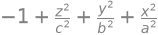

In [11]:
x, y, z = sp.symbols("x,y,z")
x0, y0, z0 = sp.symbols("x0,y0,z0")

P = (x, y, z)
P0 = (x0, y0, z0)

F = x**2 / a**2 + y**2 / b ** 2 + z**2 / c**2 - 1

F

In [12]:
grad_F = sp.Matrix([F.diff(x), F.diff(y), F.diff(z)])

display(Math(r"\nabla \bar{F} (P) = " + sp.latex(grad_F) ) )

<IPython.core.display.Math object>

In [13]:
grad_F_P0 = grad_F.subs(zip(P, P0))
display(Math(r"\nabla \bar{F} (P_0) = " + sp.latex(grad_F) ) )

<IPython.core.display.Math object>

Это выражение не равно нулю, коль скоро $P_0 = (x_0, y_0, z_0) \ne 0$.

Уравнение касательной плоскости:


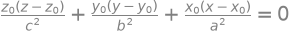

In [14]:
offsets = sp.Matrix([x - x0, y - y0, z - z0])

print("Уравнение касательной плоскости:")
display( sp.Eq(grad_F_P0.dot(offsets) / 2, 0) )

In [15]:
F_flip = grad_F.applyfunc(lambda x: x**(-1))
line_coords = F_flip.multiply_elementwise(offsets)

print("Уравнение нормальной прямой:")
display(Math(
    sp.latex(line_coords[0]) + r" = " + sp.latex(line_coords[1]) + r" = " + sp.latex(line_coords[2])
))

Уравнение нормальной прямой:


<IPython.core.display.Math object>